<a href="https://colab.research.google.com/github/apy9955/Ecommerce-sales-dashboard/blob/main/Sales_Forecast_for_Next_One_Month.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ECOMM DATA (1).xlsx to ECOMM DATA (1) (5).xlsx


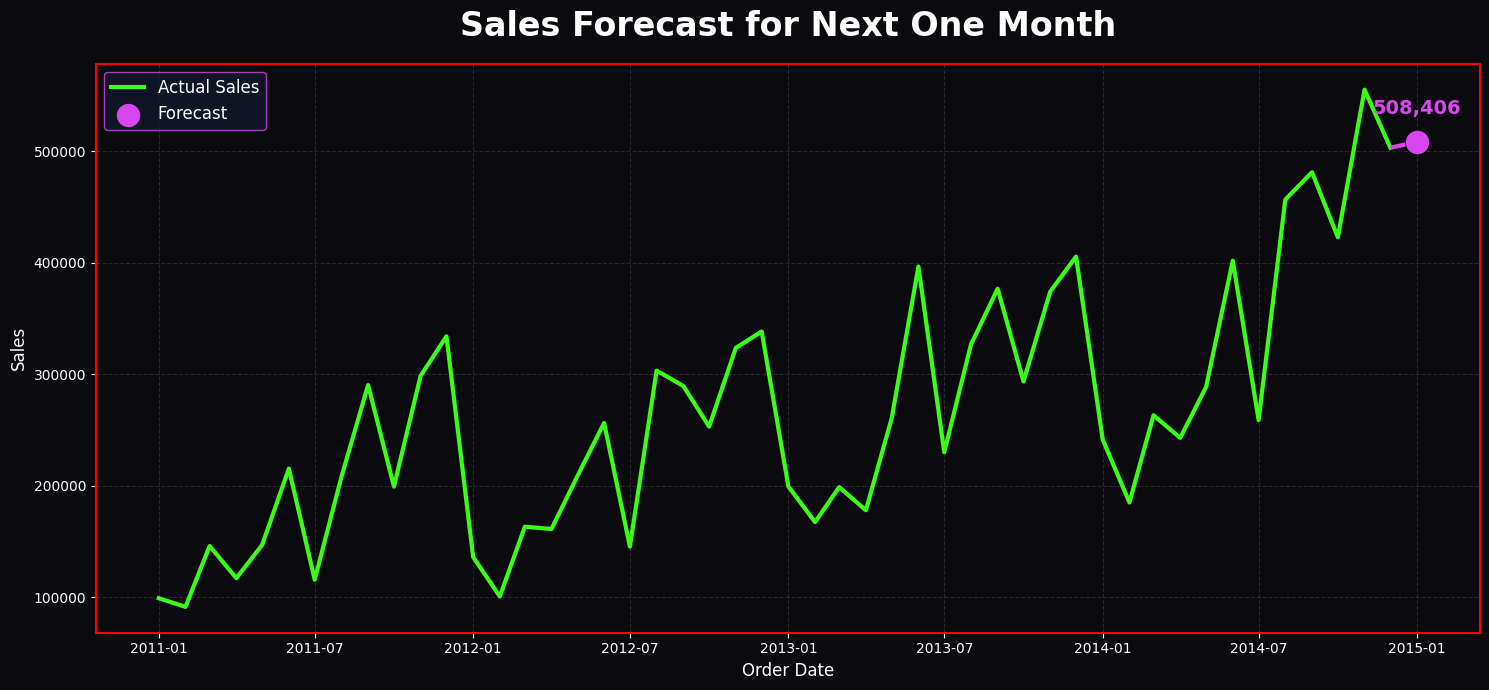

Forecast Next Month Sales : 508406


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# =====================================
# PROFESSIONAL SALES FORECAST CHART
# =====================================

!pip -q install openpyxl statsmodels

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from google.colab import files

# Upload Excel File
uploaded = files.upload()

# Read uploaded file automatically
file_name = list(uploaded.keys())[0]

# Load Data
df = pd.read_excel(file_name)

# Convert Date Column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by Date
df = df.sort_values('Order Date')

# Monthly Sales
monthly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales']
    .sum()
)

# Forecast Model
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal=None
).fit()

# Forecast Next Month
forecast = model.forecast(1)

forecast_value = round(forecast.iloc[0], 2)

# =====================================
# PROFESSIONAL DARK THEME CHART
# =====================================

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(15,7))

# Background
fig.patch.set_facecolor('#0B0B0F')
ax.set_facecolor('#0B0B0F')

# Actual Sales Line
ax.plot(
    monthly_sales.index,
    monthly_sales.values,
    color='#39FF14',
    linewidth=3,
    label='Actual Sales'
)

# Forecast Connection Line
ax.plot(
    [monthly_sales.index[-1], forecast.index[0]],
    [monthly_sales.iloc[-1], forecast.iloc[0]],
    color='#D946EF',
    linestyle='--',
    linewidth=3
)

# Forecast Point
ax.scatter(
    forecast.index,
    forecast.values,
    color='#D946EF',
    s=250,
    zorder=5,
    label='Forecast'
)

# Forecast Label
ax.annotate(
    f"{forecast_value:,.0f}",
    (forecast.index[0], forecast.iloc[0]),
    xytext=(0,20),
    textcoords='offset points',
    ha='center',
    fontsize=14,
    fontweight='bold',
    color='#D946EF'
)

# Title
ax.set_title(
    'Sales Forecast for Next One Month',
    fontsize=24,
    color='white',
    fontweight='bold',
    pad=20
)

# Axis Labels
ax.set_xlabel(
    'Order Date',
    fontsize=12,
    color='white'
)

ax.set_ylabel(
    'Sales',
    fontsize=12,
    color='white'
)

# Grid
ax.grid(
    color='gray',
    linestyle='--',
    alpha=0.25
)

# Legend
legend = ax.legend(
    fontsize=12,
    facecolor='#111827',
    edgecolor='#D946EF'
)

# Border
for spine in ax.spines.values():
    spine.set_color('#FF0000')
    spine.set_linewidth(1.5)

plt.tight_layout()

# Save High Quality PNG
plt.savefig(
    "Professional_Forecast.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='#0B0B0F'
)

plt.show()

print("="*50)
print("Forecast Next Month Sales :", round(forecast_value))
print("="*50)

# Download Image
files.download("Professional_Forecast.png")